In [ ]:
!pip install ray[serve] fastapi uvicorn numpy pandas pyarrow pyngrok

INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 20.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload runpod_artifacts_best.zip
!unzip -o runpod_artifacts_best.zip -d /content/artifacts
!ls -lh /content/artifacts/

Saving runpod_artifacts_best.zip to runpod_artifacts_best.zip
Archive:  runpod_artifacts_best.zip
  inflating: /content/artifacts/user_factors.npy  
  inflating: /content/artifacts/item_factors.npy  
  inflating: /content/artifacts/user_id_to_index.json  
  inflating: /content/artifacts/index_to_asin.json  
  inflating: /content/artifacts/asin_to_index.json  
total 328M
-rw-r--r-- 1 root root 1.6M Apr 24 01:32 asin_to_index.json
-rw-r--r-- 1 root root 1.7M Apr 24 01:32 index_to_asin.json
-rw-r--r-- 1 root root  14M Apr 24 01:31 item_factors.npy
-rw-r--r-- 1 root root 250M Apr 24 01:31 user_factors.npy
-rw-r--r-- 1 root root  62M Apr 24 01:32 user_id_to_index.json


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload ray_serve_app.py, api.py, index.html

Saving api.py to api.py
Saving index.html to index.html
Saving ray_serve_app.py to ray_serve_app.py


In [ ]:
# Already uploaded runpod_artifacts_best.zip with new model files
# Now also upload old artifacts for pagerank and metadata
from google.colab import files
uploaded = files.upload()  # upload runpod_artifacts.zip
!unzip -o runpod_artifacts.zip pagerank.csv metadata.csv -d /content/artifacts
!ls -lh /content/artifacts/

Saving runpod_artifacts.zip to runpod_artifacts.zip
Archive:  runpod_artifacts.zip
  inflating: /content/artifacts/pagerank.csv  
  inflating: /content/artifacts/metadata.csv  
total 388M
-rw-r--r-- 1 root root 1.6M Apr 24 01:32 asin_to_index.json
-rw-r--r-- 1 root root 1.7M Apr 24 01:32 index_to_asin.json
-rw-r--r-- 1 root root  14M Apr 24 01:31 item_factors.npy
-rw-r--r-- 1 root root  58M Apr 23 15:51 metadata.csv
-rw-r--r-- 1 root root 2.7M Apr 23 15:51 pagerank.csv
-rw-r--r-- 1 root root 250M Apr 24 01:31 user_factors.npy
-rw-r--r-- 1 root root  62M Apr 24 01:32 user_id_to_index.json


In [ ]:
import ray, os, sys, time
from ray import serve

os.environ["ARTIFACTS_DIR"] = "/content/artifacts"
ray.init(ignore_reinit_error=True)
serve.start(http_options={"host": "0.0.0.0", "port": "8000"})

for mod in list(sys.modules.keys()):
    if 'ray_serve_app' in mod or mod == 'api':
        del sys.modules[mod]

from ray_serve_app import als_scorer, reranker
from api import APIDeployment

api_app = APIDeployment.bind(als_scorer, reranker)
serve.run(api_app, route_prefix="/")
print("Deployed! Waiting 60s...")
time.sleep(60)
print("Ready.")

2026-04-27 19:08:39,764	ERROR services.py:1405 -- Failed to start the dashboard , return code 1
2026-04-27 19:08:39,765	ERROR services.py:1430 -- Error should be written to 'dashboard.log' or 'dashboard.err'. We are printing the last 20 lines for you. See 'https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#logging-directory-structure' to find where the log file is.
2026-04-27 19:08:39,767	ERROR services.py:1474 -- 
The last 20 lines of /tmp/ray/session_2026-04-27_19-08-01_344094_6475/logs/dashboard.log (it contains the error message from the dashboard): 
2026-04-27 19:08:08,358	INFO head.py:301 -- Loading SubprocessModule: <class 'ray.dashboard.modules.reporter.reporter_head.ReportHead'>.
2026-04-27 19:08:08,358	INFO head.py:301 -- Loading SubprocessModule: <class 'ray.dashboard.modules.serve.serve_head.ServeHead'>.
2026-04-27 19:08:08,358	INFO head.py:301 -- Loading SubprocessModule: <class 'ray.dashboard.modules.state.state_head.StateHead'>.
2026-04-27

(ServeReplica:default:ALSScorer pid=17050) ALSScorer: Loading artifacts...
(ServeReplica:default:PageRankReranker pid=17052) PageRankReranker: Loading artifacts...
(ServeReplica:default:API pid=17096) API: Ready.
(ServeReplica:default:ALSScorer pid=17050) ALSScorer: Loaded 1,307,046 users and 71,937 products.
(ServeReplica:default:PageRankReranker pid=17052) PageRankReranker: Ready. 77,633 products indexed.


INFO 2026-04-27 19:09:21,135 serve 6475 -- Application 'default' is ready at http://0.0.0.0:8000/.


Deployed! Waiting 60s...
Ready.


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3Clby2G2L8VYU9NVxqDiPK7Sjcp_6zipuDgxwgAmMF89ibBJt")
tunnel = ngrok.connect(8000)
print(f"Public URL: {tunnel.public_url}")

Public URL: https://amaretto-unwelcome-whacking.ngrok-free.dev


In [ ]:
import requests
url = tunnel.public_url
res = requests.get(f"{url}/health", headers={"X-API-Key": "smartcart-2026"})
print(res.status_code, res.json())

200 {'status': 'healthy', 'model': 'ALS rank=50 regParam=0.1 maxIter=20', 'pipeline': 'ALSScorer -> PageRankReranker', 'version': '2.0.0'}


(ServeReplica:default:API pid=17096) INFO 2026-04-27 19:10:50,310 default_API frgnpe8p 818835c7-7ae3-48d9-82ba-daab32e0d9c0 -- GET / 200 3.3ms


In [ ]:
dashboard_tunnel = ngrok.connect(8265)
print(f"Ray Dashboard: {dashboard_tunnel.public_url}")

Ray Dashboard: https://amaretto-unwelcome-whacking.ngrok-free.dev


In [ ]:
from pyngrok import ngrok
ngrok.kill()
tunnel = ngrok.connect(8000)
print(f"New URL: {tunnel.public_url}")

New URL: https://amaretto-unwelcome-whacking.ngrok-free.dev


In [ ]:
import requests
res = requests.get(
    f"{tunnel.public_url}/recommend/AGKHLEW2SOWHNMFQIJGBECAF7INQ",
    headers={"X-API-Key": "smartcart-2026"}
)
print(res.status_code)
print(res.json()['recommendations'][0]['title'])

(ServeReplica:default:ALSScorer pid=17050) INFO 2026-04-27 19:11:37,915 default_ALSScorer sn6hcjym b5f0e202-9174-4724-bc13-99eb99071b9b -- CALL score OK 35.8ms
(ServeReplica:default:API pid=17096) INFO 2026-04-27 19:11:37,828 default_API frgnpe8p b5f0e202-9174-4724-bc13-99eb99071b9b -- Started <ray.serve._private.router.SharedRouterLongPollClient object at 0x7d74ef4da210>.
(ServeReplica:default:PageRankReranker pid=17052) INFO 2026-04-27 19:11:37,972 default_PageRankReranker wuap1eqo b5f0e202-9174-4724-bc13-99eb99071b9b -- CALL rerank OK 20.1ms
(ServeReplica:default:API pid=17096) INFO 2026-04-27 19:11:37,976 default_API frgnpe8p b5f0e202-9174-4724-bc13-99eb99071b9b -- GET / 200 170.6ms


200
3X Reusable Coffee Pods Handy Gourmet Stainless Steel Mesh Filter Non BPA Kcup


In [ ]:
import requests

url = tunnel.public_url
headers = {"X-API-Key": "smartcart-2026", "ngrok-skip-browser-warning": "true"}

# Health check
res = requests.get(f"{url}/health", headers=headers)
print(f"Health   : {res.status_code} {res.json()}")

# Individual recommendation
res2 = requests.get(f"{url}/recommend/AGKHLEW2SOWHNMFQIJGBECAF7INQ", headers=headers)
print(f"Recommend: {res2.status_code} — {res2.json()['recommendations'][0]['title']}")

# Simulate
res3 = requests.post(f"{url}/simulate?n_users=100", headers=headers)
print(f"Simulate : {res3.status_code} — {res3.json()['users_simulated']} users, {res3.json()['unique_products']} unique products")

(ServeReplica:default:API pid=17096) INFO 2026-04-27 19:11:43,929 default_API frgnpe8p 19ed1bb7-da95-4119-ab97-1e48eb81789b -- GET / 200 2.5ms


Health   : 200 {'status': 'healthy', 'model': 'ALS rank=50 regParam=0.1 maxIter=20', 'pipeline': 'ALSScorer -> PageRankReranker', 'version': '2.0.0'}


(ServeReplica:default:ALSScorer pid=17050) INFO 2026-04-27 19:11:44,581 default_ALSScorer sn6hcjym 0be4a95a-55e0-45c9-9f69-c73547a0fbb9 -- CALL score OK 11.8ms
(ServeReplica:default:PageRankReranker pid=17052) INFO 2026-04-27 19:11:44,588 default_PageRankReranker wuap1eqo 0be4a95a-55e0-45c9-9f69-c73547a0fbb9 -- CALL rerank OK 4.0ms
(ServeReplica:default:API pid=17096) INFO 2026-04-27 19:11:44,591 default_API frgnpe8p 0be4a95a-55e0-45c9-9f69-c73547a0fbb9 -- GET / 200 27.3ms


Recommend: 200 — 3X Reusable Coffee Pods Handy Gourmet Stainless Steel Mesh Filter Non BPA Kcup


(ServeReplica:default:ALSScorer pid=17050) INFO 2026-04-27 19:11:45,338 default_ALSScorer sn6hcjym e14bc361-d18d-41e1-8aa8-3fd778166378 -- CALL random_user_indices OK 86.1ms
(ServeReplica:default:ALSScorer pid=17050) INFO 2026-04-27 19:11:45,765 default_ALSScorer sn6hcjym e14bc361-d18d-41e1-8aa8-3fd778166378 -- CALL score_batch OK 422.5ms
(ServeReplica:default:PageRankReranker pid=17052) INFO 2026-04-27 19:11:45,889 default_PageRankReranker wuap1eqo e14bc361-d18d-41e1-8aa8-3fd778166378 -- CALL rerank_batch OK 118.0ms
(ServeReplica:default:PageRankReranker pid=17052) INFO 2026-04-27 19:11:45,917 default_PageRankReranker wuap1eqo e14bc361-d18d-41e1-8aa8-3fd778166378 -- CALL aggregate_analytics OK 16.2ms
(ServeReplica:default:API pid=17096) INFO 2026-04-27 19:11:45,920 default_API frgnpe8p e14bc361-d18d-41e1-8aa8-3fd778166378 -- POST / 200 674.5ms


Simulate : 200 — 100 users, 475 unique products


In [ ]:
print(serve.status())

ServeStatus(proxies={'406b81a7a49ebb22b1b8be975da974113821741a45d37d4a8ea45e2a': <ProxyStatus.HEALTHY: 'HEALTHY'>}, applications={'default': ApplicationStatusOverview(status=<ApplicationStatus.RUNNING: 'RUNNING'>, message='', last_deployed_time_s=1777316940.2208602, deployments={'ALSScorer': DeploymentStatusOverview(status=<DeploymentStatus.HEALTHY: 'HEALTHY'>, status_trigger=<DeploymentStatusTrigger.CONFIG_UPDATE_COMPLETED: 'CONFIG_UPDATE_COMPLETED'>, replica_states={'RUNNING': 1}, message=''), 'PageRankReranker': DeploymentStatusOverview(status=<DeploymentStatus.HEALTHY: 'HEALTHY'>, status_trigger=<DeploymentStatusTrigger.CONFIG_UPDATE_COMPLETED: 'CONFIG_UPDATE_COMPLETED'>, replica_states={'RUNNING': 1}, message=''), 'API': DeploymentStatusOverview(status=<DeploymentStatus.HEALTHY: 'HEALTHY'>, status_trigger=<DeploymentStatusTrigger.CONFIG_UPDATE_COMPLETED: 'CONFIG_UPDATE_COMPLETED'>, replica_states={'RUNNING': 1}, message='')})}, target_capacity=None)


In [ ]:
import time
import requests
from IPython.display import clear_output

url = "http://localhost:8000"
headers = {"X-API-Key": "smartcart-2026"}

# Track timing history
history = []

print("Live Ray Serve Monitor — press Stop to exit")
print("=" * 60)

for i in range(100):
    clear_output(wait=True)

    # Quick health check to measure latency
    start = time.time()
    res = requests.get(f"{url}/health", headers=headers)
    latency = round((time.time() - start) * 1000, 1)
    history.append(latency)
    history = history[-20:]  # keep last 20

    # Get deployment status
    status = serve.status()

    print(f"SmartCart Ray Serve Monitor  [{time.strftime('%H:%M:%S')}]")
    print("=" * 60)
    print(f"\nDeployment Status:")
    for app_name, app in status.applications.items():
        for dep_name, dep in app.deployments.items():
            replicas = dep.replica_states
            health   = "🟢" if str(dep.status) == "DeploymentStatus.HEALTHY" else "🔴"
            print(f"  {health} {dep_name:<25} replicas={replicas}")

    print(f"\nAPI Latency (last {len(history)} checks):")
    avg = round(sum(history)/len(history), 1)
    mx  = max(history)
    mn  = min(history)
    print(f"  Current : {latency}ms")
    print(f"  Avg     : {avg}ms")
    print(f"  Min/Max : {mn}ms / {mx}ms")

    # ASCII bar chart of recent latencies
    print(f"\n  Latency history (ms):")
    max_h = max(history) if max(history) > 0 else 1
    for val in history:
        bar_len = int(val / max_h * 30)
        bar     = "█" * bar_len
        print(f"  {val:>6}ms |{bar}")

    time.sleep(2)

(ServeReplica:default:API pid=62578) INFO 2026-04-25 01:48:22,377 default_API 5rpj3b2n 126f9b5c-50dd-4da8-a067-ddca9548f0ec -- GET / 200 7.6ms


SmartCart Ray Serve Monitor  [01:48:22]

Deployment Status:
  🟢 ALSScorer                 replicas={'RUNNING': 1}
  🟢 PageRankReranker          replicas={'RUNNING': 1}
  🟢 API                       replicas={'RUNNING': 1}

API Latency (last 20 checks):
  Current : 18.1ms
  Avg     : 548.8ms
  Min/Max : 11.2ms / 10506.4ms

  Latency history (ms):
    29.2ms |
    25.5ms |
    18.7ms |
    24.2ms |
    28.8ms |
    43.8ms |
    17.3ms |
    20.9ms |
    33.2ms |
  10506.4ms |██████████████████████████████
    36.5ms |
    17.7ms |
    40.4ms |
    47.2ms |
    12.5ms |
    16.0ms |
    11.2ms |
    14.8ms |
    14.5ms |
    18.1ms |


(raylet) [2026-04-25 01:48:23,336 E 53556 53556] (raylet) node_manager.cc:3303: 5 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 6295cf542cc65e9848a2a5d0f0a89609e4b170298e49bd4d95be1a15, IP: 172.28.0.12) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 172.28.0.12`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.


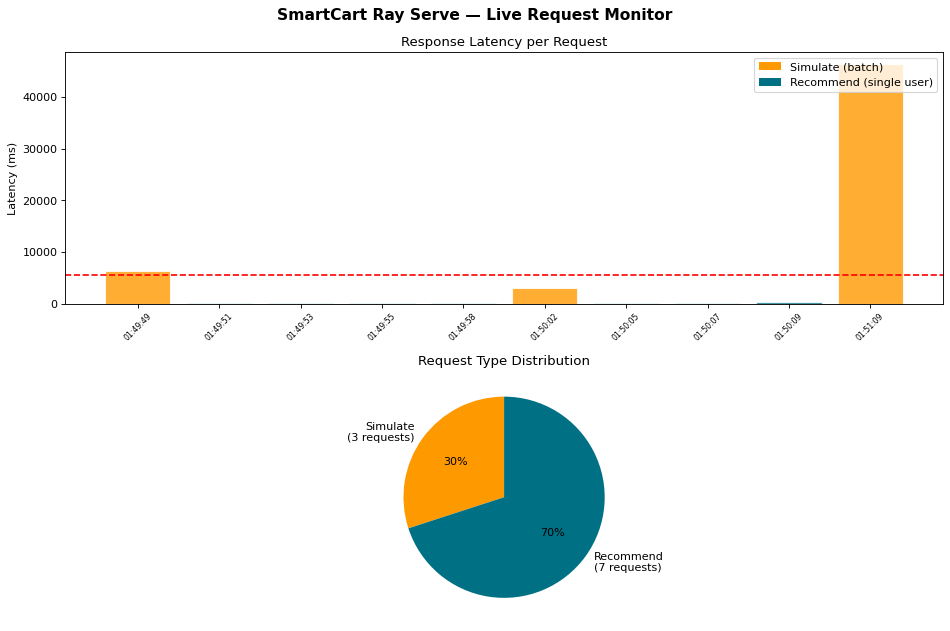

(ProxyActor pid=53701) WARNING 2026-04-25 01:51:16,818 proxy 172.28.0.12 b23487c1-87be-44ce-a9be-83fe0828dec7 -- Failed to fetch queue length for Replica(id='5rpj3b2n', deployment='API', app='default'): '1 worker(s) were killed due to the node running low on memory. Memory on the node (IP: 172.28.0.12, ID: 6295cf542cc65e9848a2a5d0f0a89609e4b170298e49bd4d95be1a15) was 12.06GB / 12.67GB (0.951379), which exceeds the memory usage threshold of 0.950000; Object store memory usage: [- objects spillable: 0; - bytes spillable: 0; - objects unsealed: 0; - bytes unsealed: 0; - objects in use: 0; - bytes in use: 0; - objects evictable: 0; - bytes evictable: 0; ; - objects created by worker: 0; - bytes created by worker: 0; - objects restored: 0; - bytes restored: 0; - objects received: 0; - bytes received: 0; - objects errored: 0; - bytes errored: 0; ; Eviction Stats:; (global lru) capacity: 3979463884; (global lru) used: 0%; (global lru) num objects: 0; (global lru) num evictions: 0; (global lru

KeyboardInterrupt: 

(ProxyActor pid=53701) WARNING 2026-04-25 01:51:18,369 proxy 172.28.0.12 b23487c1-87be-44ce-a9be-83fe0828dec7 -- Failed to fetch queue length for Replica(id='5rpj3b2n', deployment='API', app='default'): '1 worker(s) were killed due to the node running low on memory. Memory on the node (IP: 172.28.0.12, ID: 6295cf542cc65e9848a2a5d0f0a89609e4b170298e49bd4d95be1a15) was 12.06GB / 12.67GB (0.951379), which exceeds the memory usage threshold of 0.950000; Object store memory usage: [- objects spillable: 0; - bytes spillable: 0; - objects unsealed: 0; - bytes unsealed: 0; - objects in use: 0; - bytes in use: 0; - objects evictable: 0; - bytes evictable: 0; ; - objects created by worker: 0; - bytes created by worker: 0; - objects restored: 0; - bytes restored: 0; - objects received: 0; - bytes received: 0; - objects errored: 0; - bytes errored: 0; ; Eviction Stats:; (global lru) capacity: 3979463884; (global lru) used: 0%; (global lru) num objects: 0; (global lru) num evictions: 0; (global lru

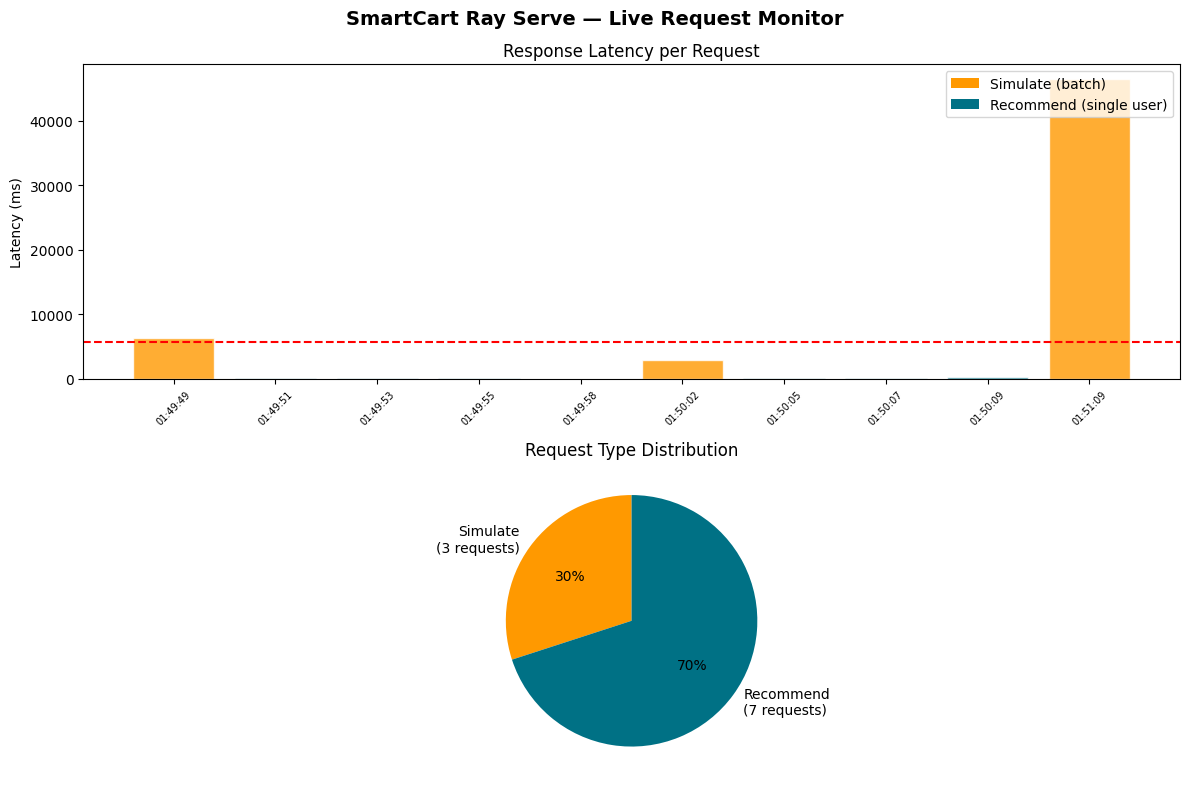

In [ ]:
import time
import requests
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display
import threading

url = "http://localhost:8000"
headers = {"X-API-Key": "smartcart-2026"}

# Shared data
latencies     = []
timestamps    = []
request_types = []
lock          = threading.Lock()

def send_requests():
    """Background thread sending mixed requests"""
    users = [
        "AGKHLEW2SOWHNMFQIJGBECAF7INQ",
        "AECPFYFQVRUWC3KGNLJIOREFP5LQ",
        "AGHLRXZCRZHZF3HGKU5LKWJLQKBA",
    ]
    i = 0
    while True:
        try:
            start = time.time()
            if i % 5 == 0:
                # Simulate request every 5th call
                r = requests.post(
                    f"{url}/simulate?n_users=500",
                    headers=headers, timeout=60
                )
                rtype = "simulate"
            else:
                r = requests.get(
                    f"{url}/recommend/{users[i % len(users)]}",
                    headers=headers, timeout=10
                )
                rtype = "recommend"

            latency = round((time.time() - start) * 1000, 1)
            with lock:
                latencies.append(latency)
                timestamps.append(time.strftime("%H:%M:%S"))
                request_types.append(rtype)
                # Keep last 30
                if len(latencies) > 30:
                    latencies.pop(0)
                    timestamps.pop(0)
                    request_types.pop(0)
        except Exception as e:
            pass
        i += 1
        time.sleep(2)

# Start background requests
t = threading.Thread(target=send_requests, daemon=True)
t.start()

# Live chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("SmartCart Ray Serve — Live Request Monitor", fontsize=14, fontweight='bold')

time.sleep(5)  # let some data accumulate

for _ in range(50):
    with lock:
        lats  = list(latencies)
        tss   = list(timestamps)
        rtypes = list(request_types)

    if len(lats) > 1:
        ax1.clear()
        ax2.clear()

        colors = ['#FF9900' if r == 'simulate' else '#007185' for r in rtypes]

        # Bar chart — latency per request
        ax1.bar(range(len(lats)), lats, color=colors, alpha=0.8, edgecolor='white')
        ax1.set_title("Response Latency per Request", fontsize=12)
        ax1.set_ylabel("Latency (ms)")
        ax1.set_xticks(range(len(tss)))
        ax1.set_xticklabels(tss, rotation=45, fontsize=7)
        ax1.axhline(y=sum(lats)/len(lats), color='red', linestyle='--',
                    label=f'Avg: {round(sum(lats)/len(lats),1)}ms')
        ax1.legend()

        # Add orange/blue legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#FF9900', label='Simulate (batch)'),
            Patch(facecolor='#007185', label='Recommend (single user)')
        ]
        ax1.legend(handles=legend_elements, loc='upper right')

        # Pie chart — request type distribution
        sim_count = rtypes.count('simulate')
        rec_count = rtypes.count('recommend')
        ax2.pie(
            [sim_count, rec_count],
            labels=[f'Simulate\n({sim_count} requests)', f'Recommend\n({rec_count} requests)'],
            colors=['#FF9900', '#007185'],
            autopct='%1.0f%%',
            startangle=90
        )
        ax2.set_title("Request Type Distribution", fontsize=12)

        plt.tight_layout()
        plt.savefig('/content/ray_monitor.png', dpi=80, bbox_inches='tight')

        from IPython.display import clear_output, Image
        clear_output(wait=True)
        display(Image('/content/ray_monitor.png'))

    time.sleep(3)